# **Import libraries**

In [1]:
import torch
torch.cuda.is_available()

True

In [ ]:
!pip install ultralytics

In [20]:
import os  # Work with files and folders
import random  # Select random numbers or items
import yaml # Read and write YAML file (used in YOLO configs)
import cv2  # Handle and process videos or images
import numpy as np  # Handle arrays and numerical data
import pandas as pd # Work with structured data
from PIL import Image
import matplotlib.pyplot as plt  # Display images and plots
from ultralytics import YOLO # Import YOLOv8-v11 modles

# **Loading and Visualize the Data with its Labels**

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
dataset = "/content/drive/MyDrive/SP2/SP2_Child_Dataset"
train_images_path = os.path.join(dataset, "train/images")
val_images_path = os.path.join(dataset, "val/images")
test_images_path = os.path.join(dataset, "test/images")


train_labels_path = os.path.join(dataset, "train/labels")
val_labels_path = os.path.join(dataset, "val/labels")
test_labels_path = os.path.join(dataset, "test/labels")

In [6]:
class_names = ['adult','child','elevator_door']

print("Classes:")
#enumerate the index with the class name
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

Classes:
0: adult
1: child
2: elevator_door


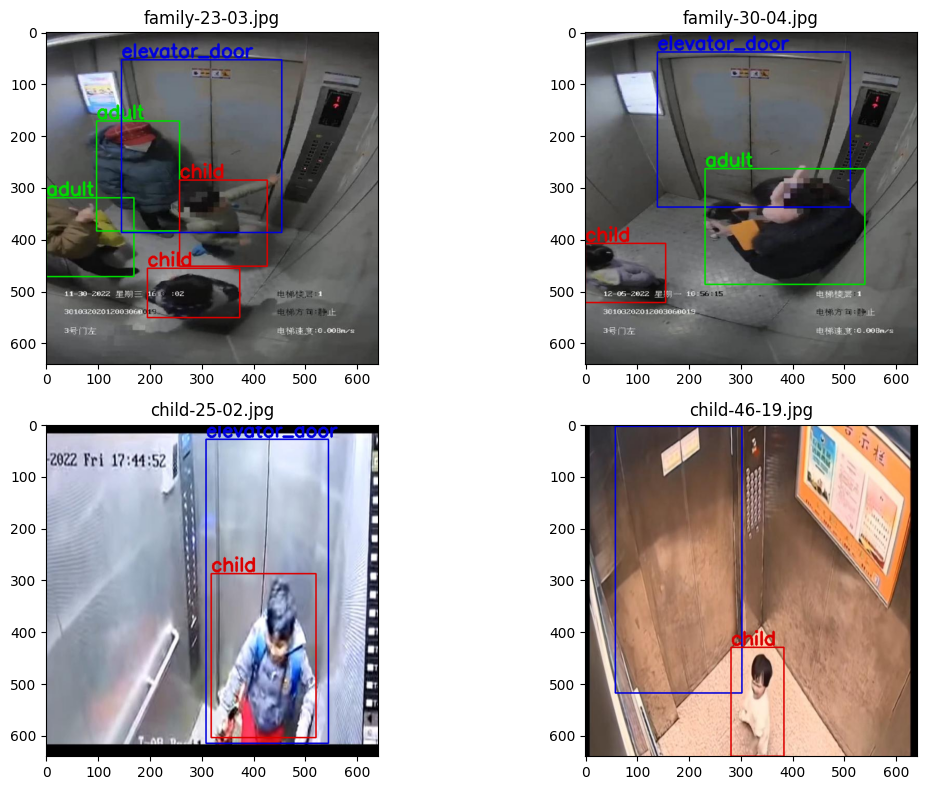

In [9]:
# Visualize 4 images randomly with bounding box

# Select 4 random image from the Train set
image_files = random.sample(os.listdir(train_images_path),4)

plt.figure(figsize = (12,8))

# Loop through each selected image
for i, img_name in enumerate(image_files):
    # Set the paths for the image and its label
    img_path = os.path.join(train_images_path,img_name)
    label_path = os.path.join(train_labels_path,img_name.replace(".jpg",".txt"))

    # Read images and convert from BGR to RGB to used by Matplotlib
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h,w,_ = img.shape

    # Read label file
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                # Extract label Values (coordinates) with label
                cls_id, x_center,y_center, bw,bh = map(float,line.strip().split())
                cls_id = int(cls_id)

                # Converts the coordinates into pixels
                x1 = int((x_center - bw/2) * w)
                y1 = int((y_center - bh/2) * h)
                x2 = int((x_center + bw/2) * w)
                y2 = int((y_center + bh/2) * h)

                if cls_id == 0:
                    # Draw the boundig box and class name
                    cv2.rectangle(img,(x1,y1),(x2,y2),(0,220,0),2)
                    cv2.putText(img,class_names[cls_id],(x1,y1-5),
                               cv2.FONT_HERSHEY_SIMPLEX,1.2,(0,220,0),3)
                elif cls_id == 1:
                    cv2.rectangle(img,(x1,y1),(x2,y2),(220,0,0),2)
                    cv2.putText(img,class_names[cls_id],(x1,y1-5),
                               cv2.FONT_HERSHEY_SIMPLEX,1.2,(220,0,0),3)
                else:
                    cv2.rectangle(img,(x1,y1),(x2,y2),(0,0,220),2)
                    cv2.putText(img,class_names[cls_id],(x1,y1-5),
                               cv2.FONT_HERSHEY_SIMPLEX,1.2,(0,0,220),3)

    plt.subplot(2,2,i+1)
    plt.title(img_name)
    plt.imshow(img)

plt.tight_layout()
plt.show()


In [12]:
# Function to count images in each split of the dataset
def count_videos(images_path):
    videos = set()
    if os.path.exists(images_path):
        for f in os.listdir(images_path):
            if not f.lower().endswith((".jpg", ".png", ".jpeg")):
                continue
            name = os.path.splitext(f)[0]
            parts = name.split("-")
            if len(parts) < 3:
                continue
            video_name = f"{parts[0]}-{int(parts[1])}"  # normalization للأرقام
            videos.add(video_name)
    return len(videos)

In [13]:
train = count_videos(train_images_path)
val = count_videos(val_images_path)
test  = count_videos(test_images_path)

print(f"Train videos: {train}")
print(f"Valid videos: {val}")
print(f"Test videos: {test}")

Train videos: 63
Valid videos: 18
Test videos: 12


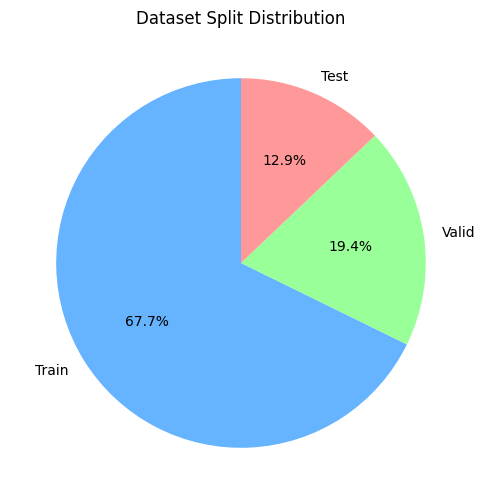

In [14]:
splits = ['Train','Valid','Test']
counts = [train,val,test]

# Plot the pie chart
plt.figure(figsize = (6,6))
plt.pie(counts,labels = splits, autopct = '%1.1f%%',startangle = 90,colors=['#66b3ff','#99ff99','#ff9999'])
plt.title("Dataset Split Distribution")
plt.show()

# **Configuring YOLOv11 for Fine-Tuning**

In [15]:
yolo_yaml = "/content/drive/MyDrive/SP2/Child/yolo_data.yaml"

yaml_content = """
train: /content/drive/MyDrive/SP2/SP2_Child_Dataset/train/images
val:   /content/drive/MyDrive/SP2/SP2_Child_Dataset/val/images
test:  /content/drive/MyDrive/SP2/SP2_Child_Dataset/test/images
nc: 3
names: ['adult', 'child', 'elevator_door']
"""
with open(yolo_yaml,'w') as f:
    f.write(yaml_content.strip())

In [16]:
model = YOLO('yolo11n.pt')
path = '/content/drive/MyDrive/SP2/Child/yolov11_custom_train'

In [17]:
results = model.train(
    data = yolo_yaml,
    epochs = 140,
    imgsz = 640,
    batch = 16,
    optimizer='SGD',
    name = path,
    augment=True,
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/SP2/Child/yolo_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=140, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov11_custom_train, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask

# **Validation Results**

In [18]:
model_path = '/content/drive/MyDrive/SP2/Child/yolov11_custom_train/weights/best.pt'
yolo_yaml = '/content/drive/MyDrive/SP2/Child/yolo_data.yaml'
model = YOLO(model_path)

Confusion matrix from training validation:


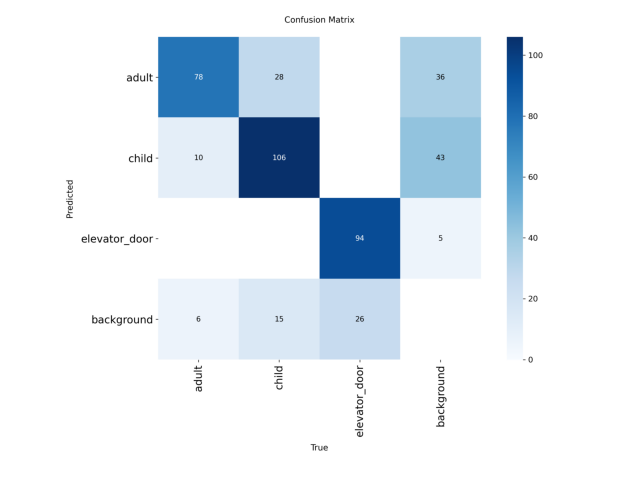

In [21]:
conf_path = os.path.join(path, "confusion_matrix.png")
print("Confusion matrix from training validation:")
img = Image.open(conf_path)
plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [22]:
metrics = model.val(split = 'val')

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 5.9±12.1 ms, read: 15.2±11.5 MB/s, size: 32.5 KB)
val: Scanning /content/drive/MyDrive/SP2/SP2_Child_Dataset/val/labels.cache... 139 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 139/139 36.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.9it/s 4.7s
                   all        139        363       0.76      0.831      0.813      0.481
                 adult         51         94      0.635      0.894      0.787       0.42
                 child        132        149      0.712      0.725      0.731      0.397
         elevator_door        120        120      0.933      0.875      0.922      0.627
Speed: 6.2ms preprocess, 6.5ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to /content/runs/

In [23]:
precision = round(float(metrics.box.mp), 3)
recall = round(float(metrics.box.mr), 3)
map50 = round(float(metrics.box.map50), 3)
map5095 = round(float(metrics.box.map), 3)

print("\n===== Validation Results =====")
print(f" Precision   : {precision}")
print(f" Recall      : {recall}")
print(f" mAP@50      : {map50}")
print(f" mAP@50-95   : {map5095}")


===== Validation Results =====
 Precision   : 0.76
 Recall      : 0.831
 mAP@50      : 0.813
 mAP@50-95   : 0.481


# **Evaluate The Model**

In [24]:
# Evaluate the model on TEST set
evaluation = "/content/drive/MyDrive/SP2/Child/evaluation"
metrics = model.val(data = yolo_yaml,
                    imgsz = 640,
                    split = 'test',
                    name = evaluation,
                    )

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 0.1±0.0 MB/s, size: 29.6 KB)
val: Scanning /content/drive/MyDrive/SP2/SP2_Child_Dataset/test/labels... 85 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 85/85 1.4it/s 1:02
val: New cache created: /content/drive/MyDrive/SP2/SP2_Child_Dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.2it/s 2.7s
                   all         85        213      0.845      0.882       0.94      0.545
                 adult         43         55       0.75      0.964      0.962      0.596
                 child         78         78      0.868      0.845      0.905       0.42
         elevator_door         80         80      0.918      0.837      0.952      0.621
Speed: 5.7ms preprocess, 6.0ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /content/drive/MyDrive/

Confusion matrix for the test results:


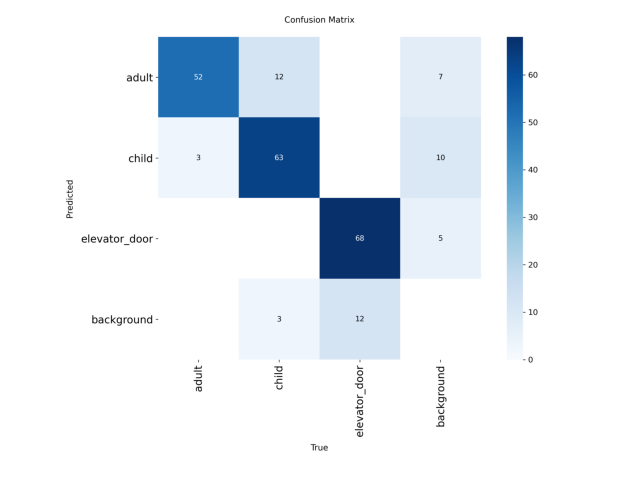

In [25]:
test_conf = "/content/drive/MyDrive/SP2/Child/evaluation/confusion_matrix.png"
print("Confusion matrix for the test results:")
img = Image.open(test_conf)
plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [26]:
precision = round(float(metrics.box.mp), 3)
recall = round(float(metrics.box.mr), 3)
map50 = round(float(metrics.box.map50), 3)
map5095 = round(float(metrics.box.map), 3)

print("\n===== Evaluation Results =====")
print(f" Precision   : {precision}")
print(f" Recall      : {recall}")
print(f" mAP@50      : {map50}")
print(f" mAP@50-95   : {map5095}")


===== Evaluation Results =====
 Precision   : 0.845
 Recall      : 0.882
 mAP@50      : 0.94
 mAP@50-95   : 0.545


# **Prediction Result**

In [28]:
from pathlib import Path
from IPython.display import Image, display

test_images = "/content/drive/MyDrive/SP2/SP2_Child_Dataset/test/images"
test_results = "/content/drive/MyDrive/SP2/Child/pred_test"

pred = model.predict(
    source=test_images,
    imgsz=640,
    conf=0.55,
    save=True,
    verbose=False,
    name= test_results
)

Results saved to /content/drive/MyDrive/SP2/Child/pred_test


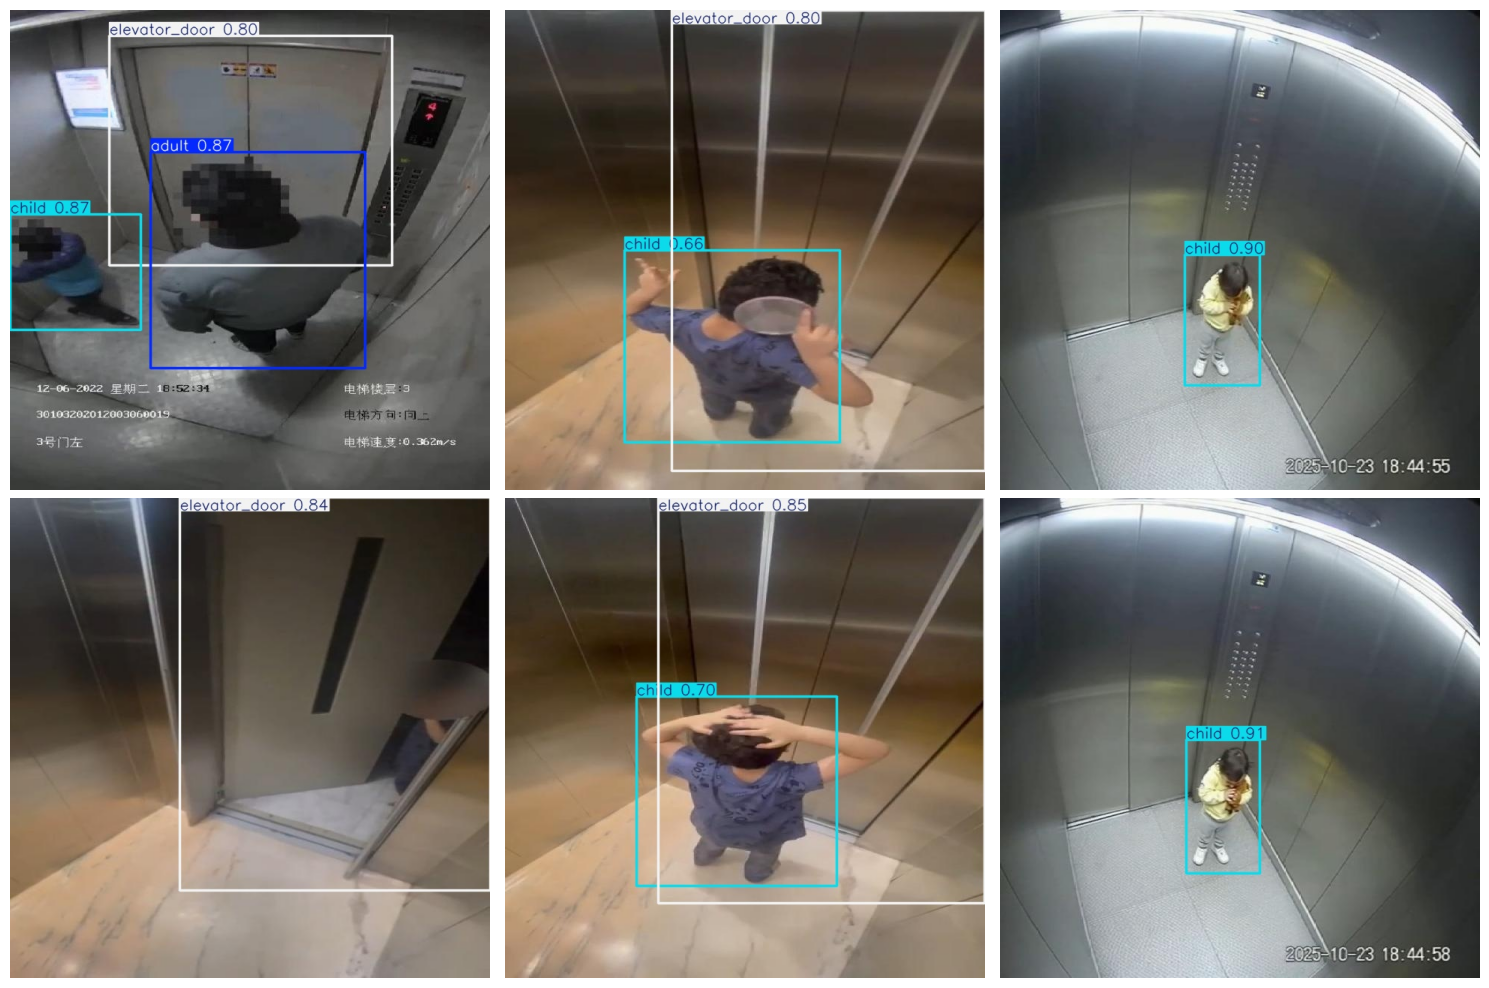

In [30]:
pred_dir = Path('/content/drive/MyDrive/SP2/Child/pred_test')
image_paths = list(pred_dir.glob("*"))
random_paths = random.sample(image_paths, 6)

plt.figure(figsize=(15, 10))

for i, img_path in enumerate(random_paths):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()